In [7]:
import sys
!{sys.executable} -m pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
ruta_csv = "../datos/datos_fatiga.csv"

df = pd.read_csv(ruta_csv)
df.head()

,fecha_hora,id_sesion,tipo_sesion,ear,mar,estado_cabeza,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos
0,2026-05-07 18:15:58.076,20260507_181554,normal,0.3049,0.0000,frente,0,0,0,0,0,0,0,0.0
1,2026-05-07 18:15:58.604,20260507_181554,normal,0.2926,0.0000,frente,0,0,0,0,0,0,0,0.0
2,2026-05-07 18:15:59.148,20260507_181554,normal,0.2929,0.0000,frente,0,0,0,0,0,0,0,0.0
3,2026-05-07 18:15:59.651,20260507_181554,normal,0.2920,0.0000,frente,0,0,0,0,0,0,0,0.0
4,2026-05-07 18:16:00.172,20260507_181554,normal,0.3041,0.0182,frente,0,0,0,0,0,0,0,0.0


In [10]:
df.shape

(17825, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17825 entries, 0 to 17824
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fecha_hora              17825 non-null  object 
 1   id_sesion               17825 non-null  object 
 2   tipo_sesion             17825 non-null  object 
 3   ear                     17825 non-null  float64
 4   mar                     17825 non-null  float64
 5   estado_cabeza           17825 non-null  object 
 6   mirando_abajo           17825 non-null  int64  
 7   parpadeos_total         17825 non-null  int64  
 8   parpadeos_por_minuto    17825 non-null  int64  
 9   cabeceos_total          17825 non-null  int64  
 10  cabeza_abajo_sostenida  17825 non-null  int64  
 11  bostezos                17825 non-null  int64  
 12  microsuenos             17825 non-null  int64  
 13  perclos                 17825 non-null  float64
dtypes: float64(3), int64(7), object(4)
mem

In [12]:
df.describe()

,ear,mar,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos
count,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000
mean,0.277862,0.016371,0.081907,43.003927,5.680449,1.146143,0.065077,1.526957,11.863001,0.107706
std,0.041283,0.071583,0.274231,44.937913,5.589446,2.230620,0.246669,3.993889,19.451857,0.219364
min,0.088800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.252000,0.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.277400,0.000000,0.000000,25.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.006700
75%,0.309000,0.014000,0.000000,61.000000,8.000000,2.000000,0.000000,0.000000,14.000000,0.080000
max,0.515200,1.030500,1.000000,201.000000,43.000000,18.000000,1.000000,14.000000,77.000000,1.000000


In [13]:
df["tipo_sesion"].value_counts()

tipo_sesion
concentrado    7406
distraido      5067
cansado        2965
normal         2387
Name: count, dtype: int64

In [14]:
import numpy as np

df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

df = df.sort_values(["id_sesion", "fecha_hora"]).reset_index(drop=True)

df["segundos"] = df.groupby("id_sesion")["fecha_hora"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

minutos = np.maximum(df["segundos"], 30) / 60.0

df["cabeceos_por_minuto"] = df["cabeceos_total"] / minutos
df["bostezos_por_minuto"] = df["bostezos"] / minutos
df["microsuenos_por_minuto"] = df["microsuenos"] / minutos

df.head()

,fecha_hora,id_sesion,tipo_sesion,ear,mar,estado_cabeza,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos,segundos,cabeceos_por_minuto,bostezos_por_minuto,microsuenos_por_minuto
0,2026-05-07 18:15:58.076,20260507_181554,normal,0.3049,0.0000,frente,0,0,0,0,0,0,0,0.0,0.000,0.0,0.0,0.0
1,2026-05-07 18:15:58.604,20260507_181554,normal,0.2926,0.0000,frente,0,0,0,0,0,0,0,0.0,0.528,0.0,0.0,0.0
2,2026-05-07 18:15:59.148,20260507_181554,normal,0.2929,0.0000,frente,0,0,0,0,0,0,0,0.0,1.072,0.0,0.0,0.0
3,2026-05-07 18:15:59.651,20260507_181554,normal,0.2920,0.0000,frente,0,0,0,0,0,0,0,0.0,1.575,0.0,0.0,0.0
4,2026-05-07 18:16:00.172,20260507_181554,normal,0.3041,0.0182,frente,0,0,0,0,0,0,0,0.0,2.096,0.0,0.0,0.0


In [15]:
features = [
    "ear",
    "mar",
    "mirando_abajo",
    "parpadeos_por_minuto",
    "perclos",
    "cabeceos_por_minuto",
    "bostezos_por_minuto",
    "microsuenos_por_minuto",
]

X = df[features].fillna(0)
y = df["tipo_sesion"]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from sklearn.metrics import classification_report

predicciones = modelo.predict(X_test)

print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

     cansado       0.99      0.97      0.98       593
 concentrado       0.96      0.95      0.96      1481
   distraido       1.00      0.98      0.99      1014
      normal       0.86      0.94      0.90       477

    accuracy                           0.96      3565
   macro avg       0.95      0.96      0.96      3565
weighted avg       0.97      0.96      0.96      3565



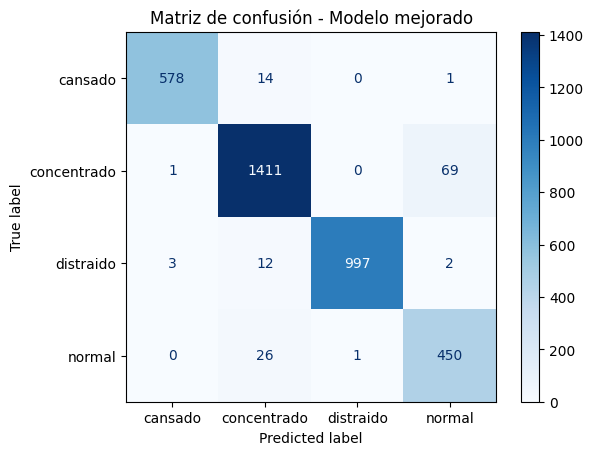

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de confusión - Modelo mejorado")
plt.show()

In [19]:
importancias = pd.DataFrame({
    "variable": features,
    "importancia": modelo.feature_importances_
}).sort_values("importancia", ascending=False)

importancias

,variable,importancia
7,microsuenos_por_minuto,0.279536
5,cabeceos_por_minuto,0.215937
0,ear,0.170354
6,bostezos_por_minuto,0.138424
4,perclos,0.058346
3,parpadeos_por_minuto,0.055479
2,mirando_abajo,0.051775
1,mar,0.030148


In [20]:
import os
import joblib

os.makedirs("../modelos", exist_ok=True)

joblib.dump(modelo, "../modelos/modelo_fatiga.pkl")
joblib.dump(features, "../modelos/columnas.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente
